In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

## Load metadata from all models

In [2]:
model_dir = '../models/text/json'
records = []

for fname in sorted(os.listdir(model_dir)):
    if not fname.endswith('_meta.json'):
        continue
    with open(os.path.join(model_dir, fname)) as f:
        records.append(json.load(f))

df = pd.DataFrame(records)
df.columns = ['Model', 'Accuracy', 'Macro F1', 'Neg F1', 'Neu F1', 'Pos F1', 'Runtime (s)']

family_map = {
    'baseline': 'Baseline',
    'naive_bayes': 'Classical',
    'logistic_regression': 'Classical',
    'svm': 'Classical',
    'mlp_text': 'Neural (sklearn)',
    'rnn_text': 'Neural (deep)',
    'glove_rnn_text': 'Neural (deep)',
}
name_map = {
    'baseline': 'Baseline',
    'naive_bayes': 'Naive Bayes',
    'logistic_regression': 'Logistic Regression',
    'svm': 'SVM',
    'mlp_text': 'MLP',
    'rnn_text': 'RNN',
    'glove_rnn_text': 'GloVe + LSTM',
}
palette = {
    'Baseline': '#bdbdbd',
    'Classical': '#4c72b0',
    'Neural (sklearn)': '#dd8452',
    'Neural (deep)': '#55a868',
}

df['Family'] = df['Model'].map(family_map)
df['Model Name'] = df['Model'].map(name_map)
df = df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
baseline_acc = df.loc[df['Model'] == 'baseline', 'Accuracy'].values[0]

## Table 1 — Full results summary

In [3]:
summary = df[['Model Name', 'Family', 'Accuracy', 'Macro F1', 'Neg F1', 'Neu F1', 'Pos F1', 'Runtime (s)']].copy()
summary = summary.rename(columns={'Model Name': 'Model'})
summary.index = range(1, len(summary) + 1)
summary.round(3)

,Model,Family,Accuracy,Macro F1,Neg F1,Neu F1,Pos F1,Runtime (s)
1,GloVe + LSTM,Neural (deep),0.733,0.732,0.719,0.673,0.805,169.950
2,Logistic Regression,Classical,0.700,0.701,0.683,0.646,0.774,1.350
3,SVM,Classical,0.682,0.682,0.654,0.620,0.772,3.231
4,Naive Bayes,Classical,0.672,0.670,0.651,0.615,0.742,0.044
5,MLP,Neural (sklearn),0.664,0.666,0.657,0.609,0.733,419.390
6,RNN,Neural (deep),0.383,0.223,0.128,0.540,0.000,90.378
7,Baseline,Baseline,0.363,0.178,0.000,0.533,0.000,0.001


## Table 2 — Rankings by metric

In [4]:
metrics = ['Accuracy', 'Macro F1', 'Neg F1', 'Neu F1', 'Pos F1']
ranks = pd.DataFrame({'Model': df['Model Name']})
for m in metrics:
    ranks[m] = df[m].rank(ascending=False).astype(int)
ranks.index = range(1, len(ranks) + 1)
ranks

,Model,Accuracy,Macro F1,Neg F1,Neu F1,Pos F1
1,GloVe + LSTM,1,1,1,1,1
2,Logistic Regression,2,2,2,2,2
3,SVM,3,3,4,3,3
4,Naive Bayes,4,4,5,4,4
5,MLP,5,5,3,5,5
6,RNN,6,6,6,6,6
7,Baseline,7,7,7,7,6


## Table 3 — Gain over baseline

In [5]:
baseline_row = df[df['Model'] == 'baseline'].iloc[0]
gains = df[df['Model'] != 'baseline'][['Model Name', 'Accuracy', 'Macro F1']].copy()
gains['Accuracy Gain'] = (gains['Accuracy'] - baseline_row['Accuracy']).round(3)
gains['Macro F1 Gain'] = (gains['Macro F1'] - baseline_row['Macro F1']).round(3)
gains['Accuracy'] = gains['Accuracy'].round(3)
gains['Macro F1'] = gains['Macro F1'].round(3)
gains = gains.rename(columns={'Model Name': 'Model'}).reset_index(drop=True)
gains.index = range(1, len(gains) + 1)
gains

,Model,Accuracy,Macro F1,Accuracy Gain,Macro F1 Gain
1,GloVe + LSTM,0.733,0.732,0.370,0.554
2,Logistic Regression,0.700,0.701,0.337,0.524
3,SVM,0.682,0.682,0.318,0.504
4,Naive Bayes,0.672,0.670,0.309,0.492
5,MLP,0.664,0.666,0.301,0.489
6,RNN,0.383,0.223,0.020,0.045


## Table 4 — Per-class F1 detail

In [6]:
f1_detail = df[['Model Name', 'Neg F1', 'Neu F1', 'Pos F1']].copy()
f1_detail['Best Class'] = f1_detail[['Neg F1', 'Neu F1', 'Pos F1']].idxmax(axis=1).str.replace(' F1', '')
f1_detail['Worst Class'] = f1_detail[['Neg F1', 'Neu F1', 'Pos F1']].idxmin(axis=1).str.replace(' F1', '')
f1_detail = f1_detail.rename(columns={'Model Name': 'Model'}).reset_index(drop=True)
f1_detail.index = range(1, len(f1_detail) + 1)
f1_detail.round(3)

,Model,Neg F1,Neu F1,Pos F1,Best Class,Worst Class
1,GloVe + LSTM,0.719,0.673,0.805,Pos,Neu
2,Logistic Regression,0.683,0.646,0.774,Pos,Neu
3,SVM,0.654,0.620,0.772,Pos,Neu
4,Naive Bayes,0.651,0.615,0.742,Pos,Neu
5,MLP,0.657,0.609,0.733,Pos,Neu
6,RNN,0.128,0.540,0.000,Neu,Pos
7,Baseline,0.000,0.533,0.000,Neu,Neg


## Chart 1 — Accuracy comparison

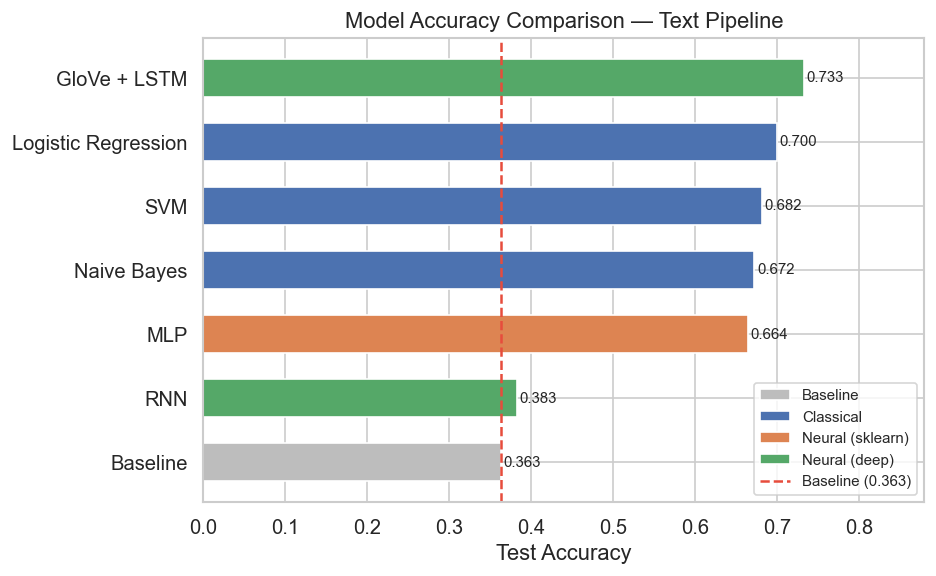

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_df = df.sort_values('Accuracy')
bars = ax.barh(
    plot_df['Model Name'], plot_df['Accuracy'],
    color=[palette[f] for f in plot_df['Family']], edgecolor='white', height=0.6
)
ax.axvline(baseline_acc, color='#e74c3c', linestyle='--', linewidth=1.5)
for bar, val in zip(bars, plot_df['Accuracy']):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9)
ax.set_xlabel('Test Accuracy')
ax.set_title('Model Accuracy Comparison — Text Pipeline')
ax.set_xlim(0, 0.88)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=l) for l, c in palette.items()]
legend_elements.append(plt.Line2D([0], [0], color='#e74c3c', linestyle='--', label=f'Baseline ({baseline_acc:.3f})'))
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

## Chart 2 — Per-class F1 comparison

C:\Users\jonah\AppData\Local\Temp\ipykernel_35360\1524858031.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')


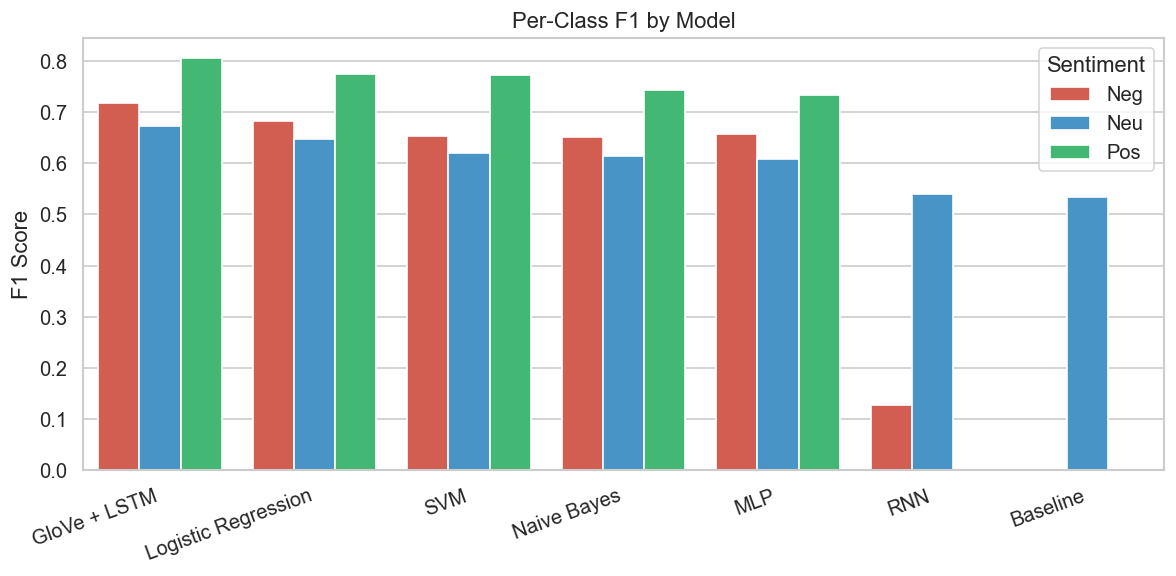

In [8]:
f1_melt = df.melt(
    id_vars='Model Name', value_vars=['Neg F1', 'Neu F1', 'Pos F1'],
    var_name='Class', value_name='F1'
)
f1_melt['Class'] = f1_melt['Class'].str.replace(' F1', '')

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=f1_melt, x='Model Name', y='F1', hue='Class',
    palette={'Neg': '#e74c3c', 'Neu': '#3498db', 'Pos': '#2ecc71'},
    ax=ax, edgecolor='white'
)
ax.set_xlabel('')
ax.set_ylabel('F1 Score')
ax.set_title('Per-Class F1 by Model')
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
ax.legend(title='Sentiment')
plt.tight_layout()
plt.show()

## Chart 3 — Metrics heatmap

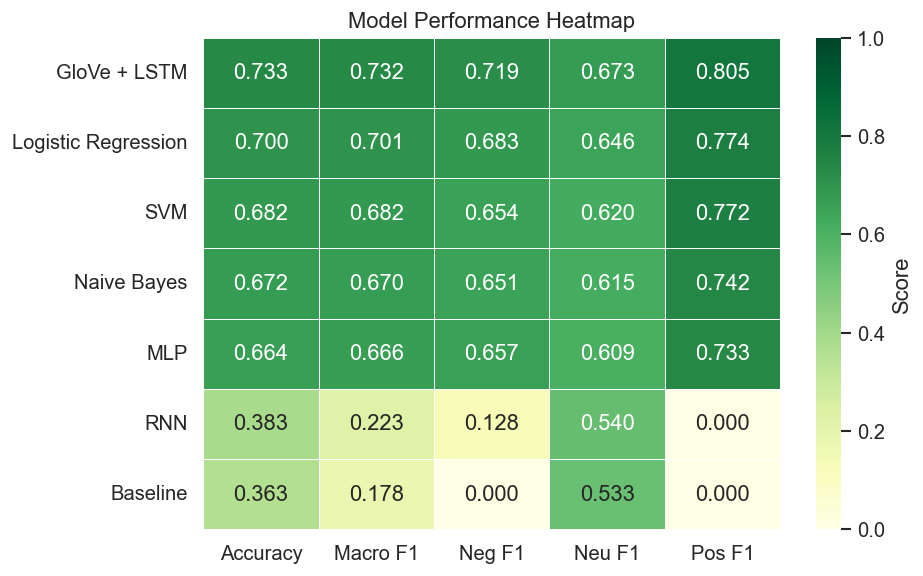

In [9]:
heat_df = df.set_index('Model Name')[['Accuracy', 'Macro F1', 'Neg F1', 'Neu F1', 'Pos F1']].round(3)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    heat_df, annot=True, fmt='.3f', cmap='YlGn',
    linewidths=0.5, linecolor='white',
    vmin=0, vmax=1, ax=ax, cbar_kws={'label': 'Score'}
)
ax.set_title('Model Performance Heatmap')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## Chart 4 — Accuracy vs. runtime tradeoff

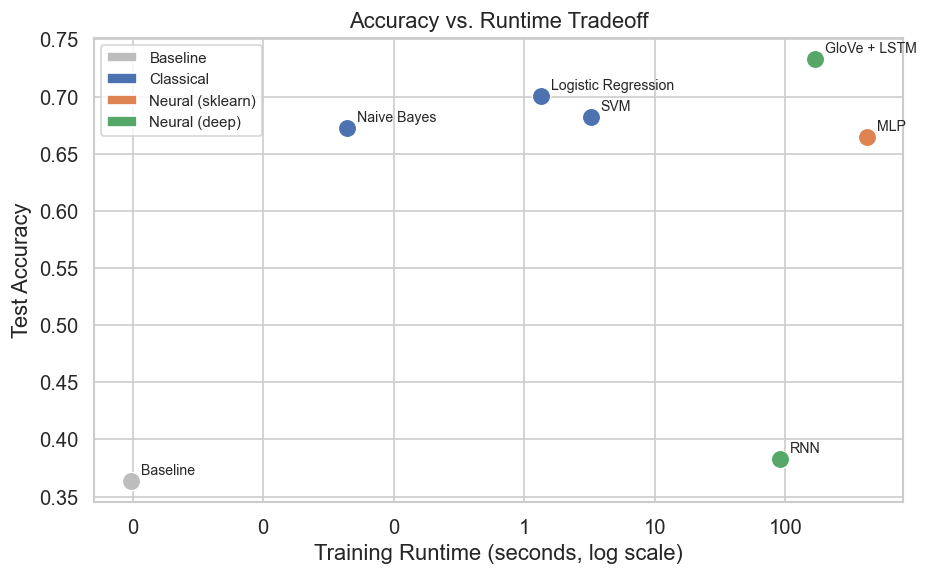

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
for _, row in df.iterrows():
    color = palette[row['Family']]
    ax.scatter(row['Runtime (s)'], row['Accuracy'], color=color, s=120, zorder=3, edgecolors='white', linewidth=0.8)
    ax.annotate(
        row['Model Name'],
        (row['Runtime (s)'], row['Accuracy']),
        textcoords='offset points', xytext=(6, 4), fontsize=8.5
    )
ax.set_xscale('log')
ax.set_xlabel('Training Runtime (seconds, log scale)')
ax.set_ylabel('Test Accuracy')
ax.set_title('Accuracy vs. Runtime Tradeoff')
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=l) for l, c in palette.items()]
ax.legend(handles=legend_elements, fontsize=9)
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
plt.tight_layout()
plt.show()

## Chart 5 — Gain over baseline

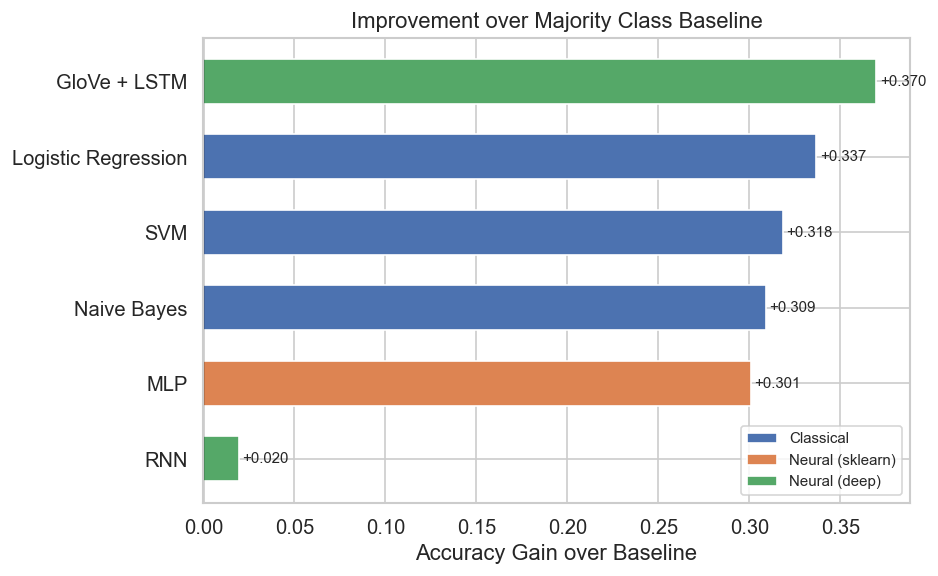

In [11]:
gain_df = df[df['Model'] != 'baseline'].copy()
gain_df['Accuracy Gain'] = gain_df['Accuracy'] - baseline_acc
gain_df = gain_df.sort_values('Accuracy Gain')

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(
    gain_df['Model Name'], gain_df['Accuracy Gain'],
    color=[palette[f] for f in gain_df['Family']], edgecolor='white', height=0.6
)
for bar, val in zip(bars, gain_df['Accuracy Gain']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
            f'+{val:.3f}', va='center', fontsize=9)
ax.set_xlabel('Accuracy Gain over Baseline')
ax.set_title('Improvement over Majority Class Baseline')
ax.axvline(0, color='black', linewidth=0.8)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=l) for l, c in palette.items() if l != 'Baseline']
ax.legend(handles=legend_elements, fontsize=9)
plt.tight_layout()
plt.show()

## Chart 6 — Runtime comparison

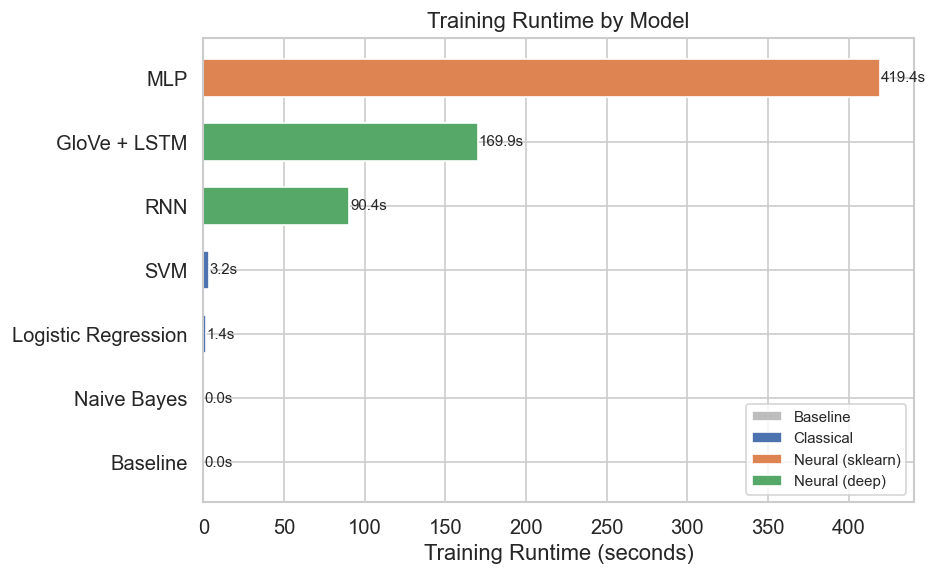

In [12]:
runtime_df = df.sort_values('Runtime (s)')

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(
    runtime_df['Model Name'], runtime_df['Runtime (s)'],
    color=[palette[f] for f in runtime_df['Family']], edgecolor='white', height=0.6
)
for i, (_, row) in enumerate(runtime_df.iterrows()):
    ax.text(row['Runtime (s)'] + 0.5, i, f"{row['Runtime (s)']:.1f}s", va='center', fontsize=9)
ax.set_xlabel('Training Runtime (seconds)')
ax.set_title('Training Runtime by Model')
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=l) for l, c in palette.items()]
ax.legend(handles=legend_elements, fontsize=9)
plt.tight_layout()
plt.show()